# Load Data

In [4]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from statsmodels.stats.sandwich_covariance import cov_cluster
from IPython.display import HTML
from stargazer.stargazer import Stargazer
import sys
import gc
import os
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [41]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Define required columns based on usage in the notebook
required_columns = [
    'isBounty',
    'userId',
    'year',
    'timestamp',
    'timeSinceFirstActivityDays',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'answeredBeforeBounty',
    'questionEverHadBounty'
]

df = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed.parquet',
                    columns=required_columns)

print(df.columns)

# Convert timestamp to datetime if it's not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Filter to remove all rows where timestamp is before or at January 27, 2009 = introduction of bounty stem
cutoff_date = pd.to_datetime('2009-01-27')
df = df[df['timestamp'] > cutoff_date]

# Recalculate userFEIsBounty after filtering
df['userFEIsBounty'] = df.groupby("userId")["isBounty"].transform(lambda x: x - x.mean())
df['logtimeSinceFirstActivityDays'] = np.log(1 + df['timeSinceFirstActivityDays'])
df['lognumQuestionsAskedAT'] = np.log(1 + df['numQuestionsAskedAT'])
df['lognumHelpProvidedAT'] = np.log(1 + df['numHelpProvidedAT'])

print(f"Data shape after filtering: {df.shape}")
print(f"Date range after filtering: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.info()

Index(['isBounty', 'userId', 'year', 'timestamp', 'timeSinceFirstActivityDays',
       'numHelpProvidedAT', 'numQuestionsAskedAT', 'answeredBeforeBounty',
       'questionEverHadBounty', 'bountyAmount'],
      dtype='object')
Data shape after filtering: (32628854, 14)
Date range after filtering: 2009-01-27 00:00:02.727000 to 2025-03-31 23:59:12.307000
<class 'pandas.core.frame.DataFrame'>
Index: 32628854 entries, 0 to 32857729
Data columns (total 14 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   isBounty                       int64         
 1   userId                         int64         
 2   year                           int32         
 3   timestamp                      datetime64[ns]
 4   timeSinceFirstActivityDays     float64       
 5   numHelpProvidedAT              int64         
 6   numQuestionsAskedAT            int64         
 7   answeredBeforeBounty           int64         
 8   questionEverHadBounty

In [42]:
df.to_parquet('../data/study_datasets/user_answers_bounty_processed_dateFiltered.parquet')

In [43]:
# Define required columns based on usage in the notebook
df = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed_dateFiltered.parquet',)

print(f"Data shape after filtering: {df.shape}")
print(f"Date range after filtering: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.info()

Data shape after filtering: (32628854, 14)
Date range after filtering: 2009-01-27 00:00:02.727000 to 2025-03-31 23:59:12.307000
<class 'pandas.core.frame.DataFrame'>
Index: 32628854 entries, 0 to 32857729
Data columns (total 14 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   isBounty                       int64         
 1   userId                         int64         
 2   year                           int32         
 3   timestamp                      datetime64[ns]
 4   timeSinceFirstActivityDays     float64       
 5   numHelpProvidedAT              int64         
 6   numQuestionsAskedAT            int64         
 7   answeredBeforeBounty           int64         
 8   questionEverHadBounty          int64         
 9   bountyAmount                   int64         
 10  userFEIsBounty                 float64       
 11  logtimeSinceFirstActivityDays  float64       
 12  lognumQuestionsAskedAT         float64     

# Get Descriptives

In [49]:
# Define columns for descriptive statistics
descriptive_columns = [
    'isBounty',
    'numQuestionsAskedAT',
    'numHelpProvidedAT',
    'timeSinceFirstActivityDays',
    'questionEverHadBounty',
    'answeredBeforeBounty',
    'userFEIsBounty'
]

def calculate_descriptives(data, columns):
    """Calculate descriptive statistics (μ, σ, min, max) for specified columns"""
    stats_dict = {}

    for col in columns:
        if col in data.columns:
            # Handle non-numeric columns by skipping them or converting
            if data[col].dtype in ['object', 'category']:
                continue

            stats_dict[col] = {
                'μ': data[col].mean(),
                'σ': data[col].std(),
                'min': data[col].min(),
                'max': data[col].max()
            }
        else:
            print(f"Warning: Column '{col}' not found in data")
    return pd.DataFrame(stats_dict).T

# Calculate overall descriptive statistics
print("=== DESCRIPTIVE STATISTICS ===")
overall_stats = calculate_descriptives(df, descriptive_columns)
print(overall_stats.round(4))

=== DESCRIPTIVE STATISTICS ===
                                   μ          σ     min         max
isBounty                      0.0112     0.1053  0.0000      1.0000
numQuestionsAskedAT          13.9949    38.5922  0.0000   3072.0000
numHelpProvidedAT           731.3261  3264.1492  0.0000  85078.0000
timeSinceFirstActivityDays  945.6309  1032.0043  0.0000   6082.1702
questionEverHadBounty         0.0190     0.1363  0.0000      1.0000
answeredBeforeBounty          0.0036     0.0596  0.0000      1.0000
userFEIsBounty                0.0000     0.0991 -0.9231      1.0000


In [45]:
len(df)

32628854

In [46]:
bucket_labels = [
    "< 1 Week", 
    "1 Week - 1 Month", 
    "1 - 6 Months", 
    "6 - 12 Months", 
    "1 - 3 Years", 
    "3 - 6 Years", 
    "> 6 Years"
]

def create_tenure_buckets(df):
    # Define the bin edges in days
    # 1 week = 7 days
    # 1 month ≈ 30 days
    # 6 months ≈ 180 days
    # 1 year = 365 days
    # 3 years = 1095 days
    # 6 years = 2190 days
    bins = [
        -np.inf, 7, 30, 180, 365, 
        1095, 2190, np.inf
    ]
    
    # Create the new column
    df['tenure_bucket'] = pd.cut(
        df['timeSinceFirstActivityDays'], 
        bins=bins, 
        labels=bucket_labels, 
        right=True # Includes the upper edge (e.g., exactly 7 days goes into "< 1 Week")
    )
    
    return df

# Apply to your dataframe
df = create_tenure_buckets(df)

# Check the distribution
print(df['tenure_bucket'].value_counts().sort_index())

tenure_bucket
< 1 Week            3472672
1 Week - 1 Month    1543301
1 - 6 Months        4056452
6 - 12 Months       3549802
1 - 3 Years         9354084
3 - 6 Years         6516790
> 6 Years           4135753
Name: count, dtype: int64


In [47]:
df_bounty_only = df[(df['questionEverHadBounty'] == 1)].reset_index(drop=True)
df_bounty_only['userFEIsBounty'] = df_bounty_only.groupby("userId")["isBounty"].transform(lambda x: x - x.mean())

In [48]:
overall_stats = calculate_descriptives(df_bounty_only, descriptive_columns)
print(overall_stats.round(4))

                                   μ          σ     min         max
isBounty                      0.5915     0.4916  0.0000      1.0000
numQuestionsAskedAT          12.5930    38.0453  0.0000   2088.0000
numHelpProvidedAT           290.9453  1507.1438  0.0000  84239.0000
timeSinceFirstActivityDays  951.9008  1022.9969  0.0000   6038.9360
questionEverHadBounty         1.0000     0.0000  1.0000      1.0000
answeredBeforeBounty          0.1881     0.3908  0.0000      1.0000
userFEIsBounty                0.0000     0.3012 -0.9941      0.9808
bountyAmount                  0.0000     0.0000  0.0000      0.0000


# 1. Main Bounty Effect

In [18]:
# --- Define a Lightweight Proxy Class ---
class CachedResult:
    """
    A tiny wrapper that mimics a Statsmodels result object.
    Stores params, pvalues, summary text, and the covariance matrix.
    """
    def __init__(self, model_res):
        # 1. Copy key statistics
        self.params = model_res.params
        self.pvalues = model_res.pvalues
        self.bse = model_res.bse
        self.tvalues = getattr(model_res, 'tvalues', None)
        self.rsquared = getattr(model_res, 'rsquared', None)
        self.nobs = getattr(model_res, 'nobs', None)
        
        # 2. Store Covariance Matrix (small KxK dataframe/array)
        self._cov_params = model_res.cov_params()
        
        # 3. Store the summary text internally
        self._summary_text = model_res.summary().as_text()

    def summary(self):
        """Returns a wrapper so .as_text() can still be called."""
        return self._summary_text

    def cov_params(self):
        """Returns the stored covariance matrix."""
        return self._cov_params

def fit_model(formula, model_name, data, cache_dir='model_cache', force_refit=False):
    if not os.path.exists(cache_dir):
        os.makedirs(cache_dir)
        
    cache_path = os.path.join(cache_dir, f"{model_name}.pkl")

    # --- 1. Try Loading from Cache ---
    if os.path.exists(cache_path) and not force_refit:
        print(f"✓ Found cache for {model_name}. Loading...")
        try:
            # Loads the tiny CachedResult object
            model_proxy = joblib.load(cache_path)
            
            # PROOF: It works just like the real model
            print(model_proxy.summary())
            # print(model_proxy.params) 
            
            return model_proxy
        except Exception as e:
            print(f"⚠ Corrupt cache for {model_name}: {e}. Refitting...")

    # --- 2. Fit New Model ---
    print(f"Fitting Model {model_name}...")
    
    try:
        gc.collect()

        if 'userFEIsBounty' in formula:
            subset_data = data[data.groupby("userId")["userId"].transform('size') > 1].reset_index(drop=True)
            # Note: The 'groups' here is likely the culprit for your file size!
            fit_obj = smf.ols(formula=formula, data=subset_data).fit(
                cov_type='cluster', cov_kwds={'groups': subset_data['userId']}
            )
            del subset_data
        else:
            fit_obj = smf.logit(formula=formula, data=data).fit(
                cov_type='cluster', cov_kwds={'groups': data['userId']}
            )

        print(fit_obj.summary())
        
        # --- 3. Save Proxy to Cache ---
        print(f"Saving {model_name} to cache...")
        
        # Create the lightweight proxy
        proxy = CachedResult(fit_obj)
        
        # Save the proxy, NOT the original fit_obj
        joblib.dump(proxy, cache_path, compress=3)

        del fit_obj
        gc.collect()
        return proxy

    except Exception as e:
        print(f"✗ Error fitting model {model_name}: {str(e)}")
        gc.collect()
        return False

In [19]:
# Non-FE Models
formula1 = "isBounty ~ tenure_bucket  + C(year)"

# FE Models
formula2 = "userFEIsBounty ~ tenure_bucket + C(year)"

model_names = ["1", "2", "1_sameq", "2_sameq"]
formulas = [formula1, formula2, formula1, formula2]
data = [df, df, df_bounty_only, df_bounty_only]

for i, (formula, name, d) in enumerate(zip(formulas, model_names, data)):
    print(f"Processing {i+1}/{len(formulas)}")
    fit_model(formula, name, d)

Processing 1/4
✓ Found cache for 1. Loading...
                           Logit Regression Results                           
Dep. Variable:               isBounty   No. Observations:             32628854
Model:                          Logit   Df Residuals:                 32628831
Method:                           MLE   Df Model:                           22
Date:                Wed, 31 Dec 2025   Pseudo R-squ.:                0.001154
Time:                        01:11:06   Log-Likelihood:            -2.0039e+06
converged:                       True   LL-Null:                   -2.0062e+06
Covariance Type:              cluster   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -4.8091      0.023   -205.366      0.000      -4.855      -4.763
tenure_bucket[T

✓ Found cache for 2_sameq. Loading...
                            OLS Regression Results                            
Dep. Variable:         userFEIsBounty   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     11.05
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           4.05e-39
Time:                        02:36:59   Log-Likelihood:            -1.7081e+05
No. Observations:              442102   AIC:                         3.417e+05
Df Residuals:                  442079   BIC:                         3.419e+05
Df Model:                          22                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

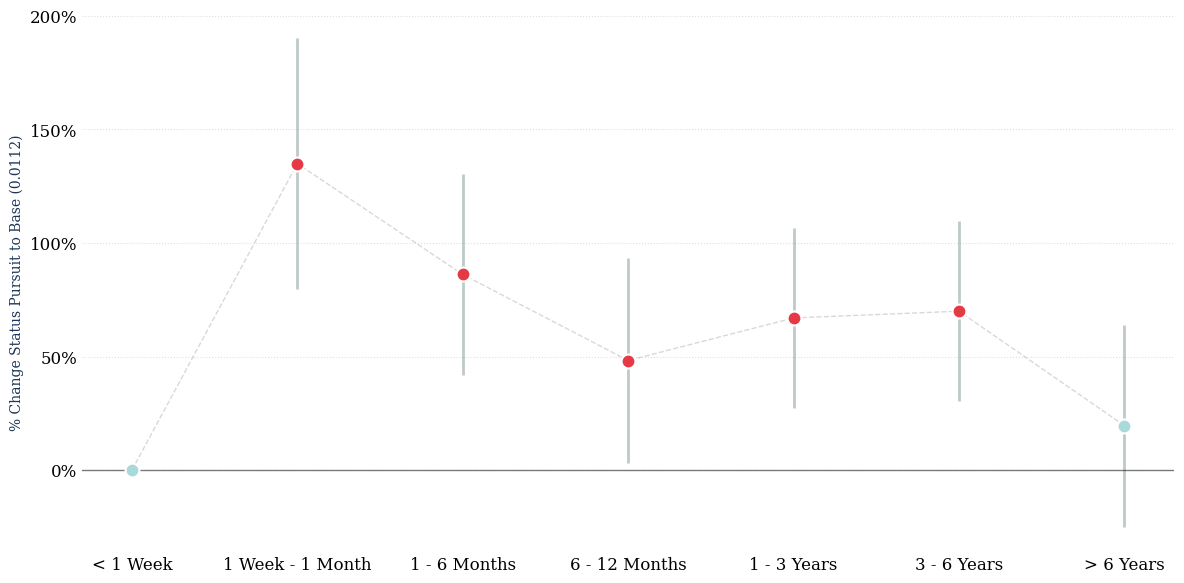

In [39]:
model = fit_model('userFEIsBounty ~ tenure_bucket + C(year)', '2_sameq', df_bounty_only)

def visualize_tenure_main_effect(model, bucket_labels, scaling_factor=0.0112):
    """
    Visualizes the main effect of tenure_bucket using a custom Tufte-inspired style.
    Values are displayed as percentages of the base probability.
    
    Parameters:
    - model: The fitted statsmodels object
    - bucket_labels: List of tenure bucket labels in order
    - scaling_factor: Base probability to divide estimates by (default 0.0112)
    """
    params = model.params
    cov = model.cov_params()
    results = []
    
    # --- 1. Data Extraction ---
    for t_level in bucket_labels:
        term_name = f"tenure_bucket[T.{t_level}]"
        
        if term_name in params.index:
            beta = params[term_name]
            var = cov.loc[term_name, term_name]
            se = np.sqrt(var)
        else:
            # Reference category
            beta = 0.0
            se = 0.0
            
        # Scale by base probability AND convert to percentage (multiply by 100)
        rel_beta_pct = (beta / scaling_factor) * 100
        rel_se_pct = (se / scaling_factor) * 100
        
        results.append({
            'tenure_bucket': t_level,
            'relative_effect_pct': rel_beta_pct,
            'se_pct': rel_se_pct
        })

    res_df = pd.DataFrame(results)

    # --- 2. Plotting (Custom Style) ---
    
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 12
    })

    fig, ax = plt.subplots(figsize=(12, 6))
    
    x_pos = np.arange(len(res_df))
    y = res_df['relative_effect_pct']
    yerr = 1.96 * res_df['se_pct']
    
    # --- Logic for Coloring ---
    # Significant if the 95% CI does not overlap 0
    is_significant = (y - yerr > 0) | (y + yerr < 0)
    colors = ['#E63946' if sig else '#A8DADC' for sig in is_significant] 

    # Plot Error bars 
    ax.errorbar(
        x_pos, y, yerr=yerr, fmt='none', 
        ecolor='#2F4F4F', alpha=0.3, elinewidth=2, capsize=0
    )

    # Plot Connecting Line
    ax.plot(x_pos, y, color='gray', alpha=0.3, linewidth=1, linestyle='--')

    # Plot Points
    for x, val, c in zip(x_pos, y, colors):
        ax.scatter(x, val, color=c, s=100, zorder=5, edgecolors='white', linewidth=1.5)

    # --- Formatting ---
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    
    # X-axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels(res_df['tenure_bucket'], rotation=0)

    # Y-axis Formatter (Add % symbol)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

    # Remove spines ("Floating" style)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Ticks and Grid
    ax.tick_params(axis='both', length=0) 
    ax.grid(axis='y', linestyle=':', alpha=0.4)

    # Typography
    ax.set_ylabel(f"% Change Status Pursuit to Base ({scaling_factor})", color='#1d3557', fontsize=10)

    plt.tight_layout()
    plt.savefig('status_strength.pdf')
    plt.show()
    
# Example usage:
visualize_tenure_main_effect(model, bucket_labels)